## 1.1 — Install & Import Libraries

In [2]:
# WHY: We need these core libraries for data loading and exploration
import pandas as pd          # Tabular data manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Statistical visualization
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings: show all columns, clean float format
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 1.2 — Load the Dataset (Real GTD or Synthetic Sample)

In [3]:
# ============================================================
# OPTION A: Load real GTD (if you downloaded it)
# ============================================================
GTD_PATH = '../data/raw/gtd.csv'   # Change to .xlsx if needed

if os.path.exists(GTD_PATH):
    # WHY low_memory=False: GTD has mixed types in some columns
    df = pd.read_csv(GTD_PATH, encoding='latin-1', low_memory=False)
    print(f'✅ Real GTD loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

else:
    print('⚠️  GTD not found. Loading synthetic sample dataset...')
    print('   Download the real dataset from https://www.start.umd.edu/gtd/')
    
    # ============================================================
    # OPTION B: Synthetic dataset matching GTD structure
    # WHY: So you can run and understand all code before obtaining real data
    # ============================================================
    import sys
    sys.path.append('../src')
    from preprocessing.sample_data_generator import generate_sample_gtd
    df = generate_sample_gtd(n=5000)
    df.to_csv('../data/raw/gtd_sample.csv', index=False)
    print(f'✅ Sample dataset created: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Real GTD loaded: 181,691 rows × 135 columns


## 1.3 — First Look at the Data

In [4]:
# WHY: Always do a first look before any processing
# This tells us shape, data types, and sample rows
print('=' * 60)
print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('=' * 60)
df.head(3)

Dataset Shape: 181,691 rows × 135 columns


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,region_txt,provstate,city,latitude,longitude,specificity,vicinity,location,summary,crit1,crit2,crit3,doubtterr,alternative,alternative_txt,...,nhostkid,nhostkidus,nhours,ndays,divert,kidhijcountry,ransom,ransomamt,ransomamtus,ransompaid,ransompaidus,ransomnote,hostkidoutcome,hostkidoutcome_txt,nreleased,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,Central America & Caribbean,NaN,Santo Domingo,18.46,-69.95,1.00,0,NaN,NaN,1,1,1,0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,North America,Federal,Mexico city,19.37,-99.09,1.00,0,NaN,NaN,1,1,1,0.00,NaN,NaN,...,1.00,0.00,NaN,NaN,NaN,Mexico,1.00,800000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,Southeast Asia,Tarlac,Unknown,15.48,120.60,4.00,0,NaN,NaN,1,1,1,0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [5]:
# Key columns we care about for this project
# WHY: GTD has 135 columns; we only need ~20 for our analysis
KEY_COLUMNS = [
    'iyear',         # Year of attack
    'imonth',        # Month
    'iday',          # Day
    'country_txt',   # Country name
    'region_txt',    # World region
    'city',          # City
    'attacktype1_txt', # Type of attack (bombing, shooting, etc.)
    'targtype1_txt', # What was targeted (civilians, government, etc.)
    'gname',         # Terrorist group name
    'nkill',         # Number killed
    'nwound',        # Number wounded
    'nkillter',      # Terrorists killed
    'weaptype1_txt', # Weapon used
    'motive',        # Stated motive (free text)
    'summary',       # Incident summary
    'success',       # Was attack successful?
    'suicide',       # Suicide attack?
    'latitude',
    'longitude',
]

# Filter to only columns that exist in this dataset
available_cols = [c for c in KEY_COLUMNS if c in df.columns]
df_core = df[available_cols].copy()
print(f'Kept {len(available_cols)} key columns')
print(f'Missing from dataset: {set(KEY_COLUMNS) - set(available_cols)}')
df_core.head(3)

Kept 19 key columns
Missing from dataset: set()


,iyear,imonth,iday,country_txt,region_txt,city,attacktype1_txt,targtype1_txt,gname,nkill,nwound,nkillter,weaptype1_txt,motive,summary,success,suicide,latitude,longitude
0,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,Assassination,Private Citizens & Property,MANO-D,1.00,0.00,NaN,Unknown,NaN,NaN,1,0,18.46,-69.95
1,1970,0,0,Mexico,North America,Mexico city,Hostage Taking (Kidnapping),Government (Diplomatic),23rd of September Communist League,0.00,0.00,NaN,Unknown,NaN,NaN,1,0,19.37,-99.09
2,1970,1,0,Philippines,Southeast Asia,Unknown,Assassination,Journalists & Media,Unknown,1.00,0.00,NaN,Unknown,NaN,NaN,1,0,15.48,120.60


## 1.4 — Missing Values Analysis
WHY: Understanding missingness guides our cleaning strategy

In [6]:
# Calculate missing value stats
missing = pd.DataFrame({
    'Column': df_core.columns,
    'Missing Count': df_core.isnull().sum().values,
    'Missing %': (df_core.isnull().mean() * 100).round(2).values
}).sort_values('Missing %', ascending=False)

print('Missing Value Report:')
print(missing.to_string(index=False))

Missing Value Report:
         Column  Missing Count  Missing %
         motive         131130      72.17
       nkillter          66958      36.85
        summary          66129      36.40
         nwound          16311       8.98
          nkill          10313       5.68
       latitude           4556       2.51
      longitude           4557       2.51
           city            435       0.24
           iday              0       0.00
          iyear              0       0.00
         imonth              0       0.00
  targtype1_txt              0       0.00
          gname              0       0.00
     region_txt              0       0.00
attacktype1_txt              0       0.00
    country_txt              0       0.00
  weaptype1_txt              0       0.00
        suicide              0       0.00
        success              0       0.00


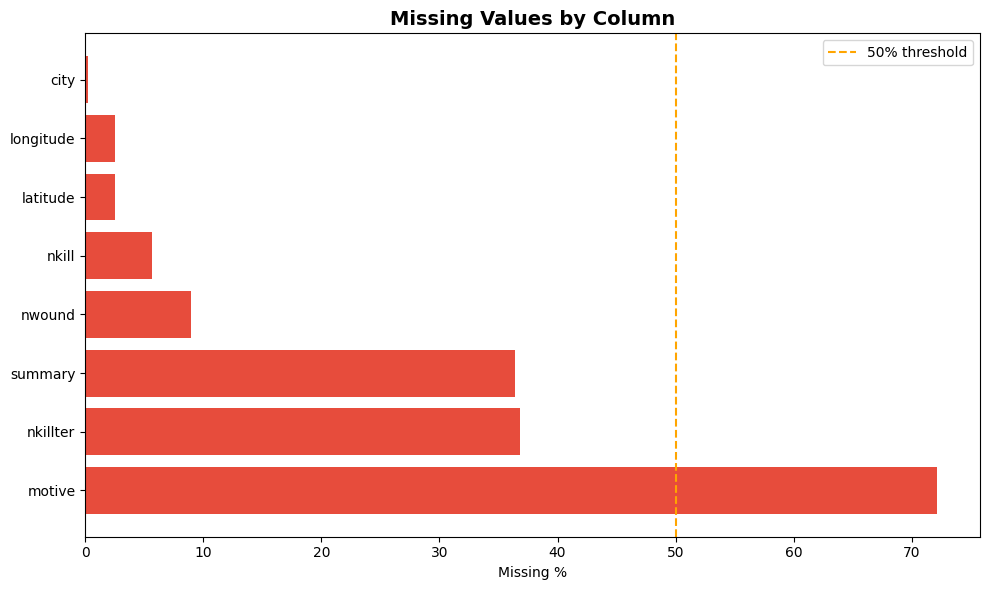

Chart saved.


In [7]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
cols_with_missing = missing[missing['Missing %'] > 0]
ax.barh(cols_with_missing['Column'], cols_with_missing['Missing %'], color='#e74c3c')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='orange', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/missing_values.png', dpi=150)
plt.show()
print('Chart saved.')

## 1.5 — Basic Statistics & Distribution

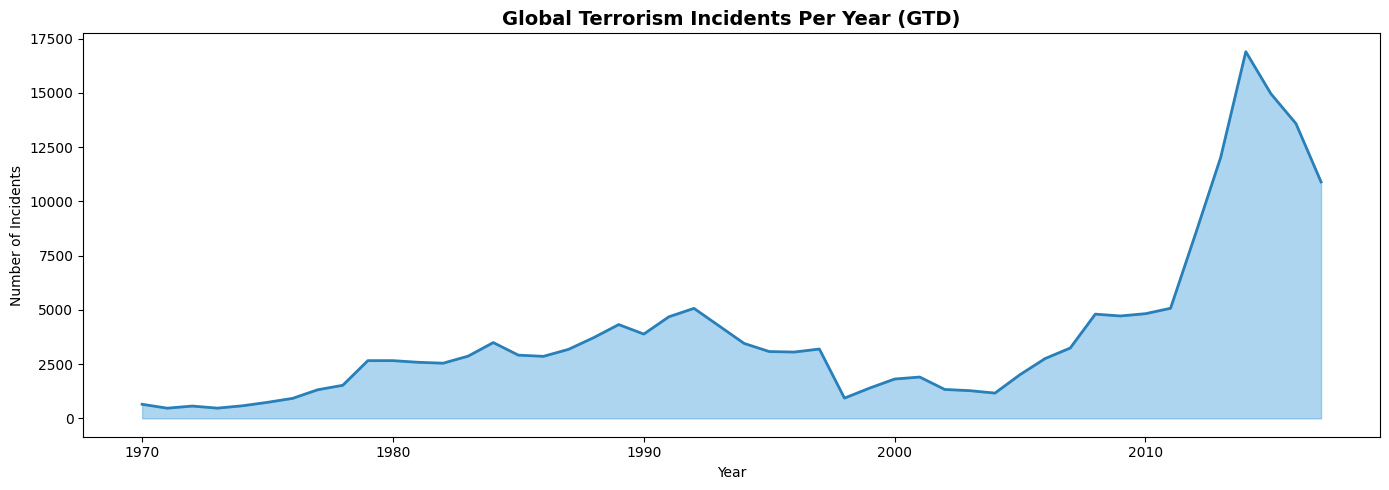

In [8]:
# Year distribution — how many attacks per year?
yearly = df_core['iyear'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(yearly.index, yearly.values, alpha=0.4, color='#3498db')
ax.plot(yearly.index, yearly.values, color='#2980b9', linewidth=2)
ax.set_title('Global Terrorism Incidents Per Year (GTD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
plt.tight_layout()
plt.savefig('../data/processed/attacks_per_year.png', dpi=150)
plt.show()

In [9]:
# Top 10 attack types
if 'attacktype1_txt' in df_core.columns:
    top_attacks = df_core['attacktype1_txt'].value_counts().head(10)
    print('Top 10 Attack Types:')
    print(top_attacks.to_string())

Top 10 Attack Types:
attacktype1_txt
Bombing/Explosion                      88255
Armed Assault                          42669
Assassination                          19312
Hostage Taking (Kidnapping)            11158
Facility/Infrastructure Attack         10356
Unknown                                 7276
Unarmed Assault                         1015
Hostage Taking (Barricade Incident)      991
Hijacking                                659


In [10]:
# Top 15 regions
if 'region_txt' in df_core.columns:
    print('\nAttacks by Region:')
    print(df_core['region_txt'].value_counts().to_string())


Attacks by Region:
region_txt
Middle East & North Africa     50474
South Asia                     44974
South America                  18978
Sub-Saharan Africa             17550
Western Europe                 16639
Southeast Asia                 12485
Central America & Caribbean    10344
Eastern Europe                  5144
North America                   3456
East Asia                        802
Central Asia                     563
Australasia & Oceania            282


In [11]:
# Top 20 most active groups
if 'gname' in df_core.columns:
    top_groups = df_core['gname'].value_counts().head(20)
    print('Top 20 Most Active Groups:')
    print(top_groups.to_string())

Top 20 Most Active Groups:
gname
Unknown                                             82782
Taliban                                              7478
Islamic State of Iraq and the Levant (ISIL)          5613
Shining Path (SL)                                    4555
Farabundo Marti National Liberation Front (FMLN)     3351
Al-Shabaab                                           3288
New People's Army (NPA)                              2772
Irish Republican Army (IRA)                          2671
Revolutionary Armed Forces of Colombia (FARC)        2487
Boko Haram                                           2418
Kurdistan Workers' Party (PKK)                       2310
Basque Fatherland and Freedom (ETA)                  2024
Communist Party of India - Maoist (CPI-Maoist)       1878
Maoists                                              1630
Liberation Tigers of Tamil Eelam (LTTE)              1606
National Liberation Army of Colombia (ELN)           1561
Tehrik-i-Taliban Pakistan (TTP)        

## 1.6 — Save for Next Step

In [12]:
# Save the filtered core dataset
# WHY: We save here so notebook 02 can pick up without reloading the full dataset
os.makedirs('../data/processed', exist_ok=True)
df_core.to_csv('../data/processed/gtd_core.csv', index=False)
print(f'✅ Saved gtd_core.csv — {df_core.shape[0]:,} rows, {df_core.shape[1]} columns')
print('\n📌 Next Step → Run: notebooks/02_preprocessing.ipynb')

✅ Saved gtd_core.csv — 181,691 rows, 19 columns

📌 Next Step → Run: notebooks/02_preprocessing.ipynb
